In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml
from pathlib import Path

ROOT = Path('..').resolve()
RAW  = ROOT / 'data' / 'raw'
PROC = ROOT / 'data' / 'processed'

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Last per zon

In [2]:
load = pd.read_parquet(PROC / 'load.parquet')
load.index = pd.to_datetime(load.index, utc=True)
print(load.shape)
load.head()

(26304, 6)


,SE-N,SE-S,NO-N,NO-S,DK,FI
time,,,,,,
2023-01-01 00:00:00+00:00,2981.229463,10679.842904,5804.823757,10926.801107,3901.620747,8566.983048
2023-01-01 01:00:00+00:00,2984.057960,10572.741567,5734.072218,10871.361014,3919.989142,8396.680291
2023-01-01 02:00:00+00:00,2979.133781,10474.184210,5700.737236,10820.020550,3785.859596,8351.241224
2023-01-01 03:00:00+00:00,2973.561647,10396.118806,5666.917302,10803.811273,3693.056884,8386.396167
2023-01-01 04:00:00+00:00,2995.000392,10417.142782,5659.003166,10873.484015,3664.949820,8562.035035


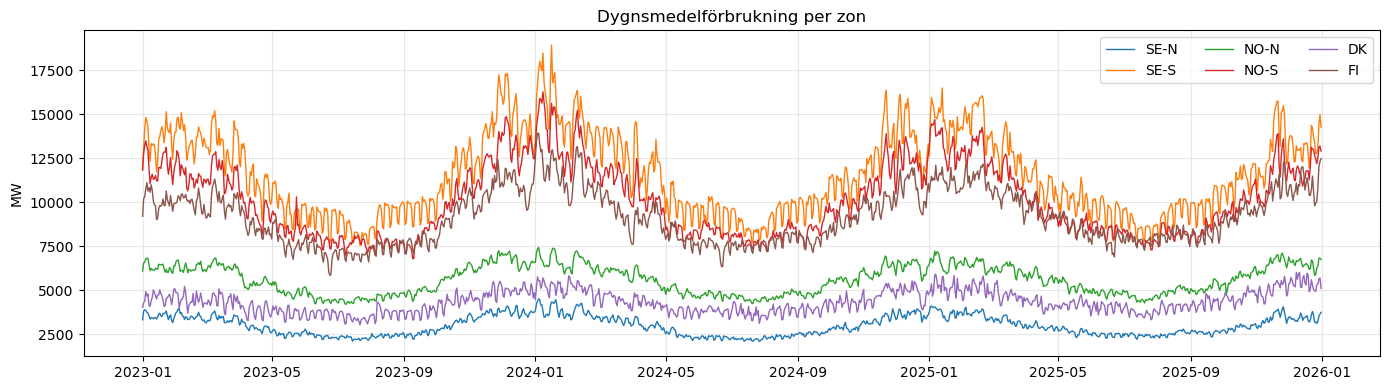

In [3]:
# Dygnsmedelförbrukning per zon
load_daily = load.resample('D').mean()

fig, ax = plt.subplots()
for col in load_daily.columns:
    ax.plot(load_daily.index, load_daily[col], label=col, lw=1)
ax.set_ylabel('MW')
ax.set_title('Dygnsmedelförbrukning per zon')
ax.legend(ncol=3)
plt.tight_layout()

In [4]:
# Årssummor (TWh)
load_twh = load.resample('YE').sum() / 1e6
load_twh.index = load_twh.index.year
load_twh.index.name = 'år'
load_twh.round(1)

,SE-N,SE-S,NO-N,NO-S,DK,FI
år,,,,,,
2023,26.3,100.8,48.9,87.6,36.3,77.8
2024,26.1,102.4,48.8,90.1,38.0,80.7
2025,26.2,100.5,49.9,89.3,39.8,82.9


## 2. Produktion per zon — rådata

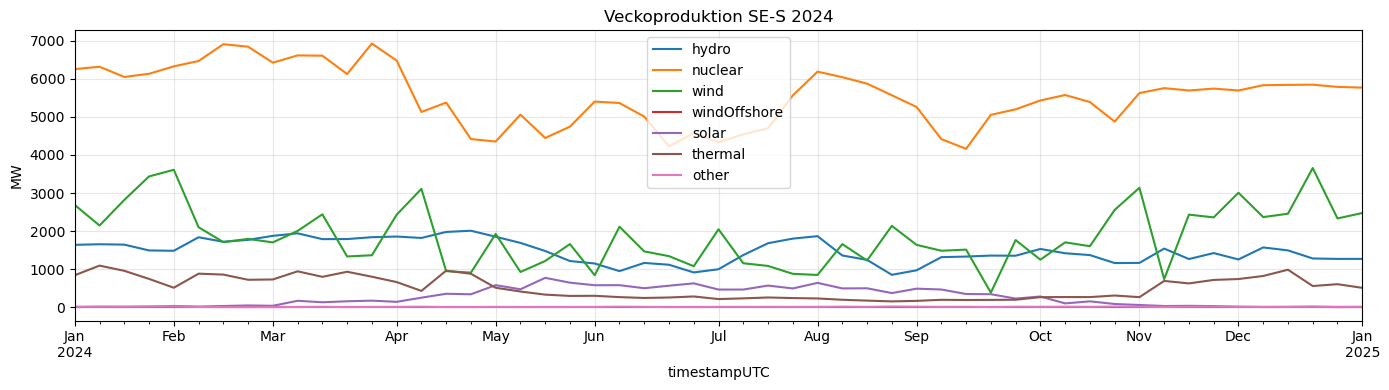

In [5]:
# Välj zon och år
ZONE = 'SE-S'
YEAR = 2024

df = pd.read_parquet(RAW / f'production_{ZONE}_{YEAR}.parquet')
df['timestampUTC'] = pd.to_datetime(df['timestampUTC'], utc=True)
df = df.set_index('timestampUTC')

prod_cols = ['hydro', 'nuclear', 'wind', 'windOffshore', 'solar', 'thermal', 'other']
df[prod_cols].resample('W').mean().plot(title=f'Veckoproduktion {ZONE} {YEAR}', ylabel='MW')
plt.tight_layout()

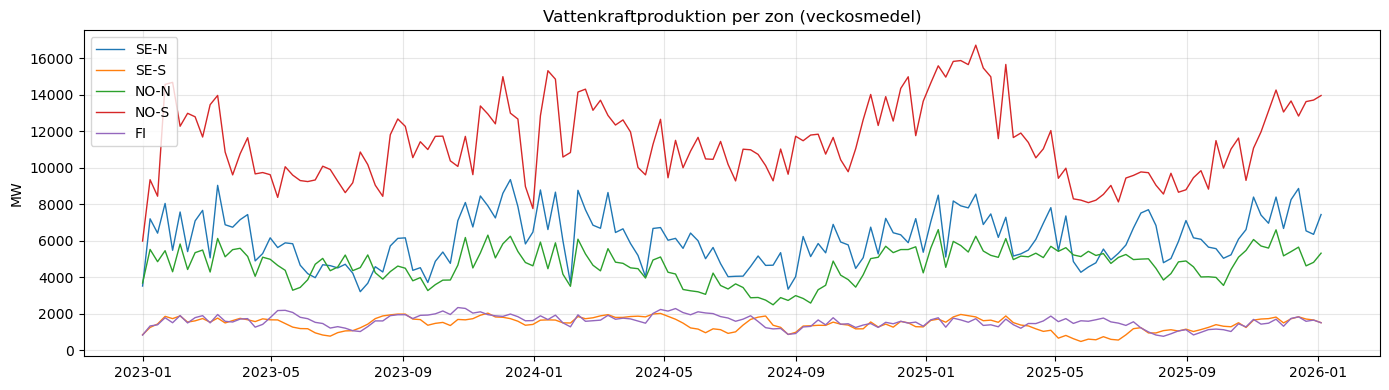

In [6]:
# Alla zoner — vattenkraftproduktion dagligen
zones = ['SE-N', 'SE-S', 'NO-N', 'NO-S', 'FI']

fig, ax = plt.subplots()
for zone in zones:
    frames = []
    for year in [2023, 2024, 2025]:
        d = pd.read_parquet(RAW / f'production_{zone}_{year}.parquet')
        d['timestampUTC'] = pd.to_datetime(d['timestampUTC'], utc=True)
        frames.append(d.set_index('timestampUTC')['hydro'])
    ts = pd.concat(frames).resample('W').mean()
    ax.plot(ts.index, ts.values, label=zone, lw=1)

ax.set_ylabel('MW')
ax.set_title('Vattenkraftproduktion per zon (veckosmedel)')
ax.legend()
plt.tight_layout()

## 3. VRE-profiler (normaliserade)

In [ ]:
vre = pd.read_parquet(PROC / 'vre_profiles.parquet')
vre.index = pd.to_datetime(vre.index, utc=True)

with open(PROC / 'vre_pnom.yaml') as f:
    vre_noms = yaml.safe_load(f)

print('p_nom (MW):')
for zone, vals in vre_noms.items():
    print(f'  {zone}: vind={vals["wind_p_nom_mw"]} MW, sol={vals["solar_p_nom_mw"]} MW')

In [ ]:
# Vindkapacitetsfaktor per zon — månadsmedel
wind_cols = [c for c in vre.columns if c.endswith('_wind')]
vre[wind_cols].resample('ME').mean().plot(
    title='Vindkapacitetsfaktor — månadsmedel', ylabel='p_max_pu'
)
plt.tight_layout()

In [ ]:
# Solkapacitetsfaktor — SE-S och FI
vre[['SE-S_solar', 'FI_solar']].resample('ME').mean().plot(
    title='Solkapacitetsfaktor — månadsmedel', ylabel='p_max_pu'
)
plt.tight_layout()

## 4. Kärnkraftsprofil

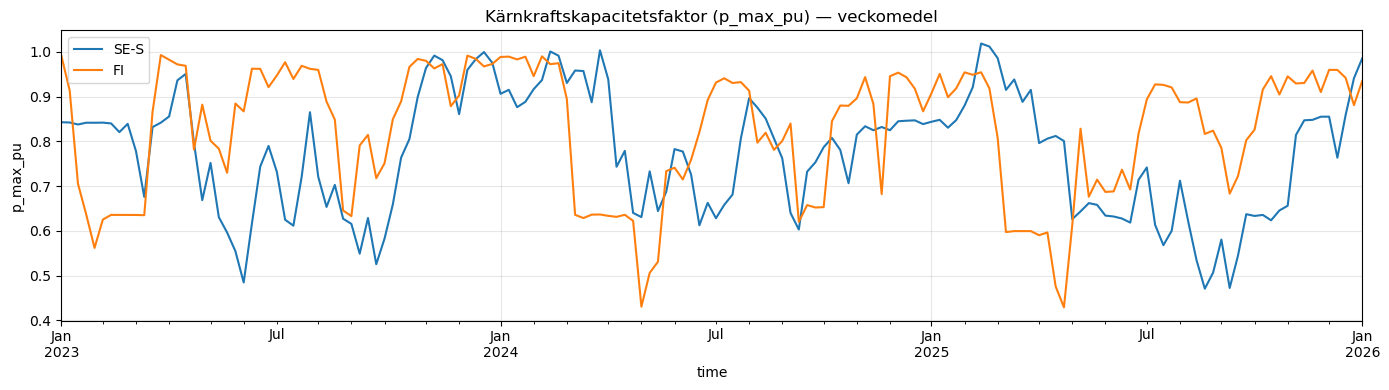

In [7]:
nuc = pd.read_parquet(PROC / 'nuclear_profile.parquet')
nuc.index = pd.to_datetime(nuc.index, utc=True)

# Visa bara zoner med kärnkraft
nuc_zones = [c for c in nuc.columns if nuc[c].max() > 0]
nuc[nuc_zones].resample('W').mean().plot(
    title='Kärnkraftskapacitetsfaktor (p_max_pu) — veckomedel',
    ylabel='p_max_pu'
)
plt.tight_layout()

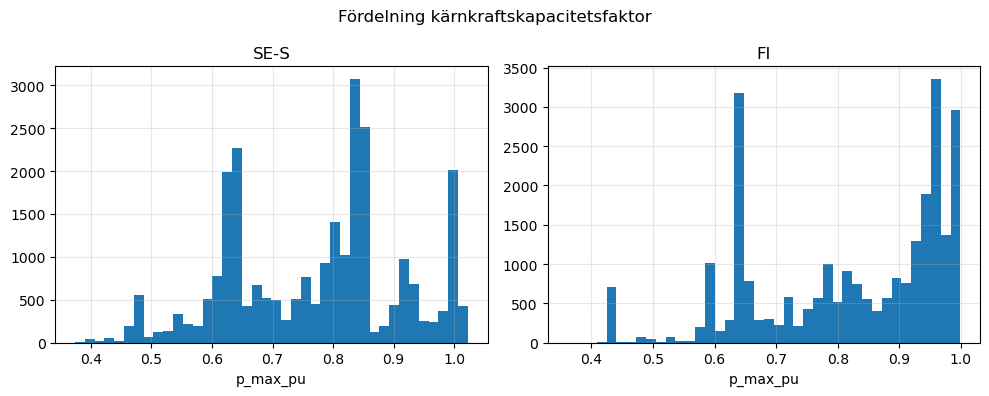

In [8]:
# Histogram — hur ofta kör kärnkraften på olika nivåer?
fig, axes = plt.subplots(1, len(nuc_zones), figsize=(10, 4))
for ax, zone in zip(axes, nuc_zones):
    nuc[zone].hist(bins=40, ax=ax)
    ax.set_title(zone)
    ax.set_xlabel('p_max_pu')
plt.suptitle('Fördelning kärnkraftskapacitetsfaktor')
plt.tight_layout()

## 5. Hydromodellen — fittade parametrar och profiler

In [9]:
with open(PROC / 'hydro_params.yaml') as f:
    hydro_params = yaml.safe_load(f)

import sys; sys.path.insert(0, str(ROOT))
from nordpsa.hydro import inflow_timeseries, load_actual_hydro

for zone, p in hydro_params.items():
    print(f"{zone}: C={p['C']:.0f} MW  A={p['A']:.0f} MW  mu=dag {p['mu']:.0f}  sigma={p['sigma']:.0f}")

FI: C=1470 MW  A=621 MW  mu=dag 140  sigma=37
NO-N: C=4661 MW  A=521 MW  mu=dag 117  sigma=10
NO-S: C=11173 MW  A=1587 MW  mu=dag 60  sigma=28
SE-N: C=6054 MW  A=781 MW  mu=dag 121  sigma=13
SE-S: C=1379 MW  A=275 MW  mu=dag 79  sigma=41


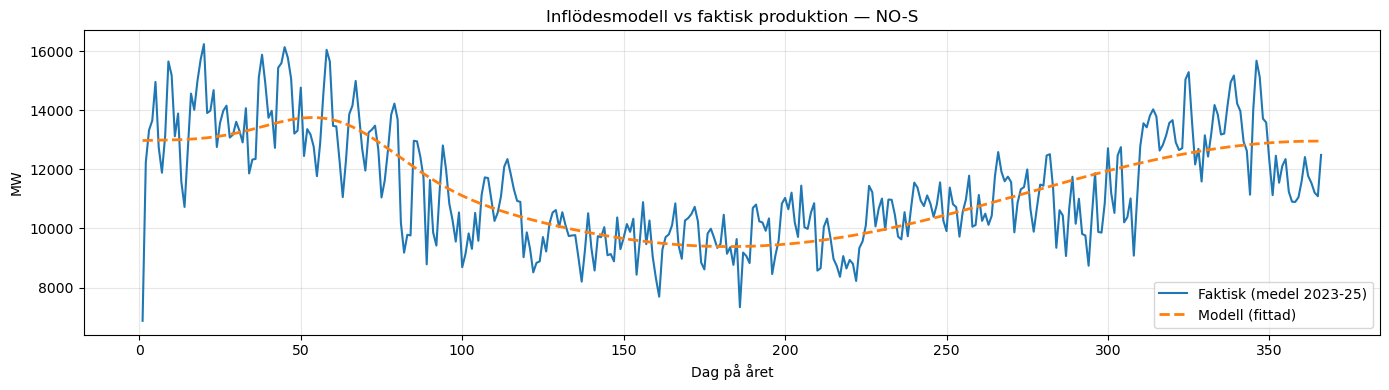

In [10]:
# Jämför fittad modell mot faktisk produktion för en zon
ZONE = 'NO-S'

actual = load_actual_hydro(ZONE)  # dagliga medelvärden (doy-indexerat)

# Generera modellprofil för ett exempelår
idx = pd.date_range('2024-01-01', '2024-12-31 23:00', freq='h', tz='UTC')
modeled_hourly = inflow_timeseries(hydro_params[ZONE], idx)
modeled_daily  = modeled_hourly.resample('D').mean()
modeled_daily.index = modeled_daily.index.dayofyear

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(actual.index,       actual.values,       label='Faktisk (medel 2023-25)', lw=1.5)
ax.plot(modeled_daily.index, modeled_daily.values, label='Modell (fittad)',         lw=2, ls='--')
ax.set_xlabel('Dag på året')
ax.set_ylabel('MW')
ax.set_title(f'Inflödesmodell vs faktisk produktion — {ZONE}')
ax.legend()
plt.tight_layout()

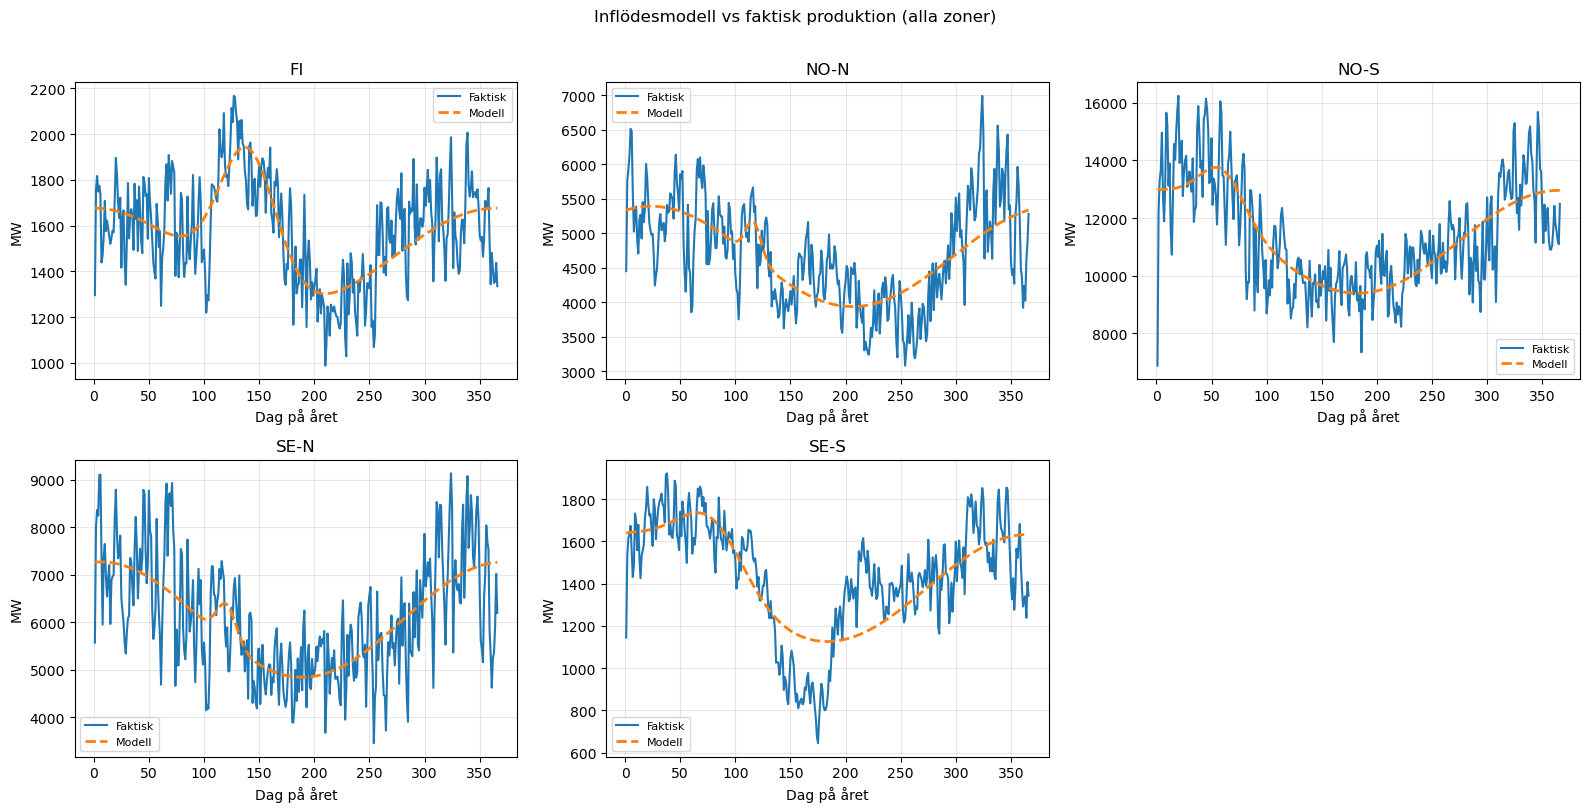

In [11]:
# Alla zoner med hydro — subplots
hydro_zones = list(hydro_params.keys())
idx = pd.date_range('2024-01-01', '2024-12-31 23:00', freq='h', tz='UTC')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, zone in zip(axes.flat, hydro_zones):
    actual  = load_actual_hydro(zone)
    modeled = inflow_timeseries(hydro_params[zone], idx).resample('D').mean()
    modeled.index = modeled.index.dayofyear

    ax.plot(actual.index,  actual.values,  label='Faktisk', lw=1.5)
    ax.plot(modeled.index, modeled.values, label='Modell',  lw=2, ls='--')
    ax.set_title(zone)
    ax.set_xlabel('Dag på året')
    ax.set_ylabel('MW')
    ax.legend(fontsize=8)

for ax in axes.flat[len(hydro_zones):]:
    ax.set_visible(False)

plt.suptitle('Inflödesmodell vs faktisk produktion (alla zoner)', y=1.01)
plt.tight_layout()

## 6. Termisk must-run

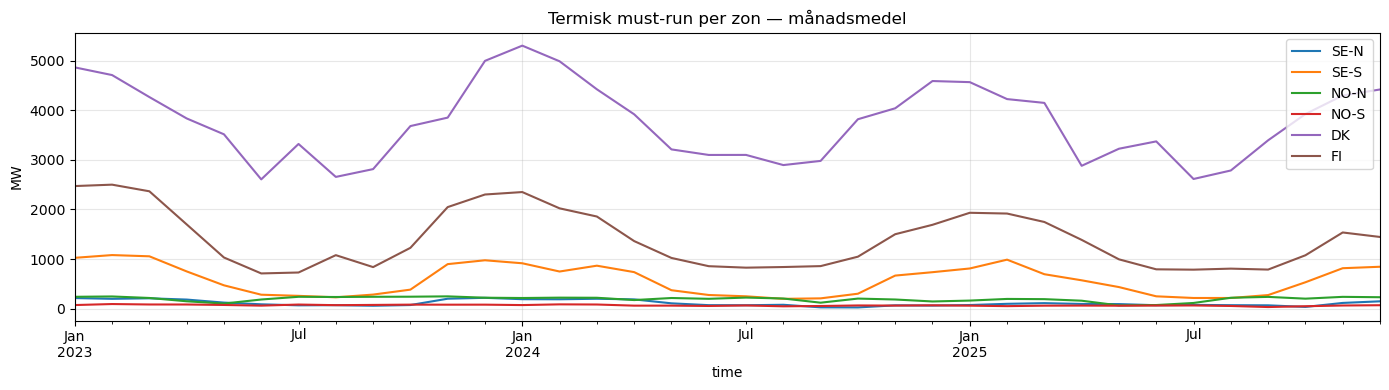

In [12]:
thermal = pd.read_parquet(PROC / 'thermal_profile.parquet')
thermal.index = pd.to_datetime(thermal.index, utc=True)

thermal.resample('ME').mean().plot(
    title='Termisk must-run per zon — månadsmedel', ylabel='MW'
)
plt.tight_layout()

## 7. Energibalans — snabbkoll per zon

In [15]:
# Jämför total produktion mot förbrukning (TWh/år)
zones = ['SE-N', 'SE-S', 'NO-N', 'NO-S', 'DK', 'FI']
rows  = []

for zone in zones:
    frames = []
    for year in [2023, 2024, 2025]:
        d = pd.read_parquet(RAW / f'production_{zone}_{year}.parquet')
        d['timestampUTC'] = pd.to_datetime(d['timestampUTC'], utc=True)
        frames.append(d.set_index('timestampUTC'))
    prod = pd.concat(frames)

    cons = load[zone]

    rows.append({
        'zon':     zone,
        'hydro':   prod['hydro'].sum()   / 1e6,
        'nuclear': prod['nuclear'].sum() / 1e6,
        'wind':    (prod['wind'] + prod['windOffshore']).sum() / 1e6,
        'solar':   prod['solar'].sum()   / 1e6,
        'thermal': (prod['thermal'] + prod['other']).sum() / 1e6,
        'last':    cons.sum()            / 1e6,
    })

balance = pd.DataFrame(rows).set_index('zon')
balance['total_prod'] = balance[['hydro','nuclear','wind','solar','thermal']].sum(axis=1)
balance['netto']      = balance['total_prod'] - balance['last']
balance.round(1)

,hydro,nuclear,wind,solar,thermal,last,total_prod,netto
zon,,,,,,,,
SE-N,160.6,0.0,66.7,0.3,2.9,78.6,230.6,152.0
SE-S,37.7,140.2,47.4,7.0,15.0,303.6,247.3,-56.3
NO-N,123.3,0.0,26.5,0.0,5.1,147.6,155.0,7.4
NO-S,299.6,0.0,16.0,0.7,1.8,266.9,318.0,51.1
DK,0.0,0.0,0.0,0.0,98.8,114.1,98.8,-15.3
FI,41.6,95.1,56.5,1.2,36.8,241.4,231.1,-10.3


In [29]:
#d = pd.read_parquet(RAW / f'production_DK_2025.parquet')
#load.loc['2025-01-15']
d

,timestamp,timestampUTC,mba,hydro,nuclear,solar,thermal,wind,windOffshore,energyStorage,other,total
0,2025-01-01 01:00:00,2025-01-01 00:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6102.633944,6102.633944
1,2025-01-01 02:00:00,2025-01-01 01:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5462.176081,5462.176081
2,2025-01-01 03:00:00,2025-01-01 02:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5366.611081,5366.611081
3,2025-01-01 04:00:00,2025-01-01 03:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5608.060596,5608.060596
4,2025-01-01 05:00:00,2025-01-01 04:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5438.345276,5438.345276
...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2025-12-31 20:00:00,2025-12-31 19:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4437.917794,4437.917794
8756,2025-12-31 21:00:00,2025-12-31 20:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5143.952471,5143.952471
8757,2025-12-31 22:00:00,2025-12-31 21:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5496.175563,5496.175563
8758,2025-12-31 23:00:00,2025-12-31 22:00:00+00:00,DK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6032.699624,6032.699624
